## SARIMAX Model
### Algorithm Motivation

The Seasonal Autoregressive Integrated Moving Average with Exogenous Variables (SARIMAX) model is an extension of the SARIMA model that incorporates external explanatory variables into the forecasting process.

In the case of maritime container throughput forecasting, the target variable is not only influenced by its own historical values and seasonal behavior, but also by external macroeconomic indicators such as exports, imports, industrial production, and retail market activity.

While the SARIMA model is capable of capturing trend, seasonality, and autocorrelation within the target series, it does not explicitly account for external drivers that may significantly affect container traffic. Therefore, SARIMAX is selected in this study to evaluate whether the inclusion of exogenous variables improves forecasting performance.

SARIMAX is particularly suitable for this dataset because:

- The target variable is a seasonal time series.
- The data exhibits trend and temporal dependence.
- External economic indicators are available and are expected to influence maritime traffic.

Thus, SARIMAX provides a statistically grounded approach for modeling both internal time-series dynamics and external economic effects.

EDA already revealed that the dataset contains:

| Data Characteristic | Observation         |
| ------------------- | ------------------- |
| Time structure      | Monthly time-series |
| Trend               | Increasing          |
| Seasonality         | Present             |
| Autocorrelation     | Significant         |
| Stationarity        | Non-stationary      |

# Theoretical Background of SARIMAX

SARIMAX is an extension of the ARIMA and SARIMA models. It combines:

- autoregressive behavior,
- differencing for stationarity,
- moving average behavior,
- seasonal structure,
- and exogenous predictors.

The SARIMAX model is generally denoted as:

SARIMAX (p, d, q) (P, D, Q, s)

Where:

- **p** = non-seasonal autoregressive order
- **d** = non-seasonal differencing order
- **q** = non-seasonal moving average order
- **P** = seasonal autoregressive order
- **D** = seasonal differencing order
- **Q** = seasonal moving average order
- **s** = seasonal period

For monthly data, the seasonal period is typically:

s = 12

Mathematically, the SARIMAX model can be expressed as:


$$
y_t = c + \sum_{i=1}^{p}\phi_i y_{t-i} + \sum_{j=1}^{q}\theta_j \epsilon_{t-j} + \sum_{k=1}^{m}\beta_k x_{t,k} + \epsilon_t
$$


Where:

- $y_t$ is the target variable at time $t$
- $x_{t,k}$ are the exogenous variables
- $\phi_i$ are autoregressive coefficients
- $\theta_j$ are moving average coefficients
- $\beta_k$ are coefficients of exogenous variables
- $\epsilon_t$ is the random error term
The seasonal part extends this formulation to capture periodic patterns repeating every \( s \) observations.

Therefore, SARIMAX is useful when the target series depends not only on its own historical values but also on external variables that influence the system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")

In [3]:
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


## Data Preprocessing for SARIMAX

Time-series forecasting models require the dataset to be structured in a specific format. The preprocessing steps performed include:

1. Converting the **Date column** into datetime format.
2. Setting the **Date column as the index** of the dataset.
3. Ensuring that the dataset follows a **monthly frequency**.

These steps ensure that the dataset behaves as a proper time-series structure where observations are ordered chronologically.

Proper indexing enables the forecasting model to correctly interpret temporal relationships between observations.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10904\572645043.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [5]:
df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


### Monthly Time Frequency

The dataset is converted into a monthly time frequency using the `asfreq('M')` method.

Maintaining a consistent frequency is important because time-series models assume that observations occur at **regular intervals**.

Setting the frequency ensures:

- Proper time indexing
- Identification of missing periods
- Accurate seasonal modeling

Since maritime trade often follows **annual seasonal cycles**, using monthly frequency allows the model to capture these seasonal patterns effectively.

In [6]:
df = df.asfreq('M')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10904\3695195888.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


In [7]:
df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


#### Checking for Missing Values

Before applying the forecasting model, it is important to verify whether the dataset contains missing values.

Missing observations can negatively impact time-series models because these models rely heavily on sequential continuity.

The `isnull().sum()` function is used to identify missing values in each column.

If missing values are present, they should be handled using appropriate techniques such as:

- interpolation
- forward filling
- backward filling

In this dataset, the absence of missing values ensures that the model can be trained without additional imputation steps.

In [8]:
df.isnull().sum()

Monthly Total TEUs                   0
United States_export_constant_us     0
United States_export_current_us      0
United States_import_constant_us     0
United States_import_current_us      0
United States_Industry_production    0
Retail_market                        0
dtype: int64

## Defining Target and Exogenous Variables

The SARIMAX model requires separation of the target variable and the external explanatory variables.

Target Variable:
Container Throughput (TEU)

Exogenous Variables:
Economic indicators such as Retail Market Index and other economic variables.

In [9]:
# Target variable
y = df['Monthly Total TEUs']

# Exogenous variables
exog = df[
    [
        'United States_export_constant_us',
        'United States_export_current_us',
        'United States_import_constant_us',
        'United States_import_current_us',
        'United States_Industry_production',
        'Retail_market'
    ]
]

#### Train-Test Split

To evaluate the forecasting performance of the SARIMAX model, the dataset is divided into **training and testing subsets**.

Unlike traditional machine learning models, time-series forecasting requires **chronological splitting** rather than random sampling.

In this study:

- **80% of the data** is used for training the model
- **20% of the data** is used for testing the model

This approach ensures that the model is trained on historical data and evaluated on future observations, mimicking real-world forecasting scenarios.

In [10]:
train_size = int(len(df) * 0.8)

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

exog_train = exog.iloc[:train_size]
exog_test = exog.iloc[train_size:]

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("exog_train shape:", exog_train.shape)
print("exog_test shape:", exog_test.shape)

y_train shape: (74,)
y_test shape: (19,)
exog_train shape: (74, 6)
exog_test shape: (19, 6)


#### SARIMAX Implementation

In this step, the SARIMAX model is implemented using the training data.

The model uses:

- the target variable: Monthly Total TEUs
- exogenous variables: macroeconomic indicators
- seasonal terms appropriate for monthly time series

At this stage, an initial SARIMAX configuration is used before hyperparameter tuning. This allows us to obtain a baseline result and assess the model’s initial forecasting performance.

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                 Monthly Total TEUs   No. Observations:                   74
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -585.947
Date:                            Mon, 16 Mar 2026   AIC                           1193.893
Time:                                    23:30:06   BIC                           1214.245
Sample:                                01-31-2009   HQIC                          1201.552
                                     - 02-28-2015                                         
Covariance Type:                              opg                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
United States_export_constant_us    -14.6159      3.317     -4.407  

#### Residuals Diagnosis

Residuals represent the difference between the actual values and the fitted values of the model.

Residual analysis is important because it helps determine whether the model has adequately captured the structure of the time series.

For a well-fitted SARIMAX model, residuals should behave like white noise. This means:

- residuals should fluctuate randomly around zero,
- residual variance should remain approximately constant,
- and no systematic pattern should remain in the residual series.

If residual patterns remain, it suggests that the model has not fully captured all information in the data.

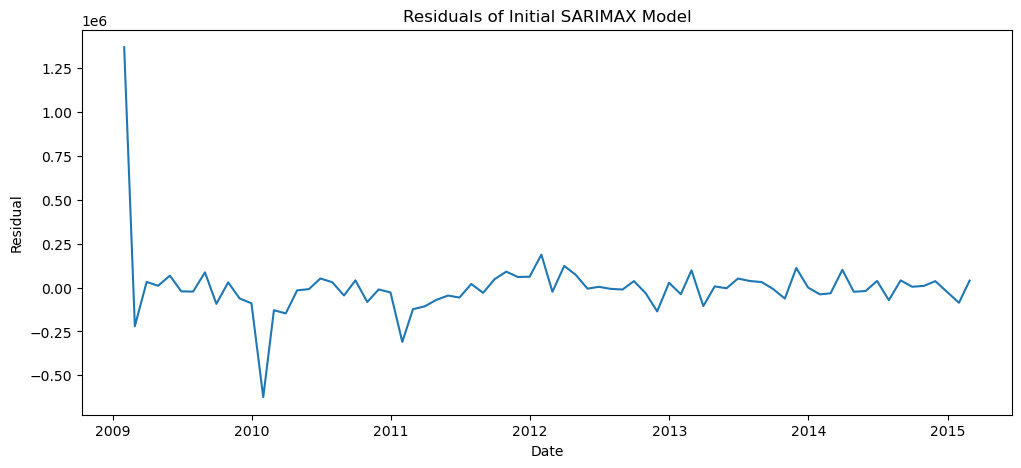

In [12]:
residuals = sarimax_result.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Residuals of Initial SARIMAX Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

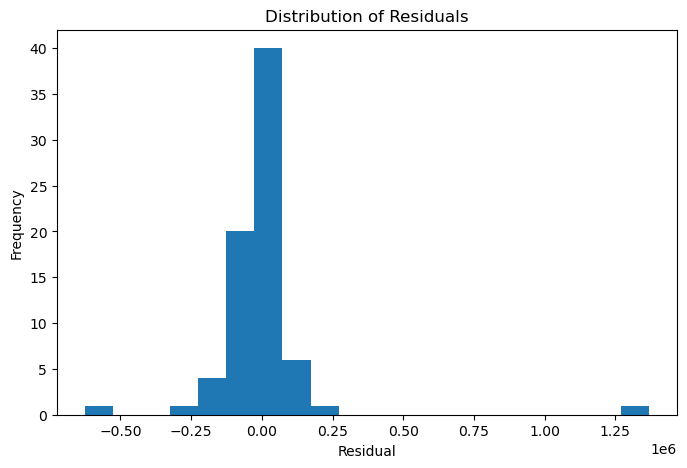

In [13]:
#Residuals should behave like white noise.
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

#### Forecast

After fitting the initial SARIMAX model, forecasts are generated for the testing period.

The model uses both:

- the learned temporal structure from the target series
- and the exogenous variables from the test period

This produces out-of-sample predictions that can be directly compared with the actual observed values in the testing set.

In [14]:
forecast_initial = sarimax_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

forecast_initial.head()

2015-03-31    573807.687433
2015-04-30    594882.852692
2015-05-31    546312.534102
2015-06-30    644924.199849
2015-07-31    594562.113211
Freq: ME, Name: predicted_mean, dtype: float64

#### Model Evaluation

The performance of the initial SARIMAX model is evaluated by comparing forecasted values with actual observations from the test dataset.

To measure the forecasting accuracy, standard evaluation metrics are used. These metrics quantify the magnitude of prediction errors and help determine how well the model performs.

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

mae_initial = mean_absolute_error(y_test, forecast_initial)
rmse_initial = math.sqrt(mean_squared_error(y_test, forecast_initial))
mape_initial = np.mean(np.abs((y_test - forecast_initial) / y_test)) * 100

print("Initial SARIMAX MAE:", mae_initial)
print("Initial SARIMAX RMSE:", rmse_initial)
print("Initial SARIMAX MAPE:", mape_initial)

Initial SARIMAX MAE: 162739.7658938189
Initial SARIMAX RMSE: 177083.6328253847
Initial SARIMAX MAPE: 22.86008716382381


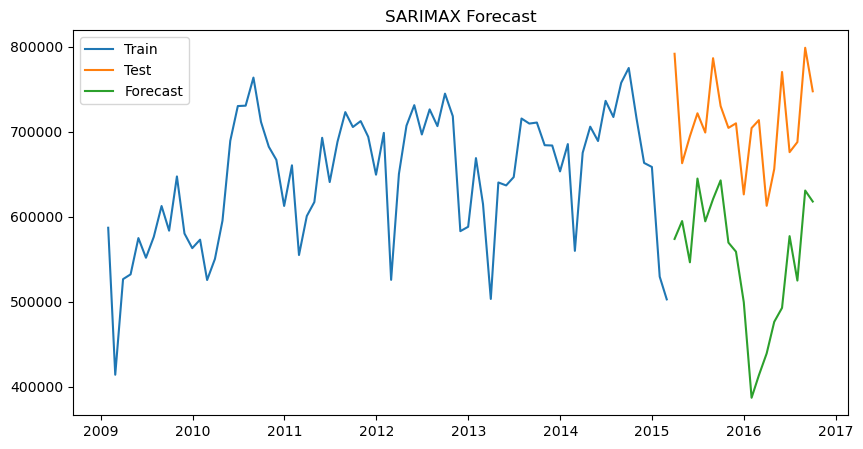

In [16]:
plt.figure(figsize=(10,5))

plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index, forecast_initial, label='Forecast')

plt.legend()
plt.title("SARIMAX Forecast")
plt.show()

#### Hyperparameter Tuning

To improve model performance, SARIMAX hyperparameters are tuned using the auto_arima function.

This process searches for the best combination of:

- non-seasonal parameters: (p, d, q)
- seasonal parameters: (P, D, Q, s)

The optimal model is selected based on the Akaike Information Criterion (AIC), which balances goodness of fit and model complexity.

A lower AIC value indicates a better trade-off between accuracy and simplicity.

In [17]:
from pmdarima import auto_arima

In [18]:
sarimax_tuning = auto_arima(
    y_train,
    exogenous=exog_train,
    seasonal=True,
    m=12,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(sarimax_tuning.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1825.189, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1810.504, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1813.776, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1823.220, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1812.467, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1807.755, Time=0.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1807.961, Time=0.10 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1807.719, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1811.477, Time=0.04 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=1807.479, Time=0.13 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1809.744, Time=0.06 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=1819.253, Time=0.08 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=1809.044, Time=0.21 sec
 ARIMA(1,1,1)(1,0,2)[12]

#### Best Parameters

After the tuning process, the best SARIMAX configuration is obtained from the auto_arima output.

These parameters represent the model structure that minimizes the AIC value on the training data and are used to build the final tuned SARIMAX model.

In [19]:
best_order = sarimax_tuning.order
best_seasonal_order = sarimax_tuning.seasonal_order

print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)

Best order: (1, 1, 0)
Best seasonal order: (1, 0, 2, 12)


#### Final SARIMAX Model Building

Using the optimal parameters obtained from the tuning process, the SARIMAX model is rebuilt.

This final model is expected to provide better forecasting performance than the initial manually specified model, since its structure has been selected systematically through hyperparameter tuning.

In [20]:
final_sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarimax_result = final_sarimax_model.fit()

print(final_sarimax_result.summary())

                                        SARIMAX Results                                        
Dep. Variable:                      Monthly Total TEUs   No. Observations:                   74
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood                -588.835
Date:                                 Mon, 16 Mar 2026   AIC                           1199.671
Time:                                         23:33:09   BIC                           1220.254
Sample:                                     01-31-2009   HQIC                          1207.449
                                          - 02-28-2015                                         
Covariance Type:                                   opg                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
United States_export_constan

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Final Forecast

The tuned SARIMAX model is now used to generate forecasts for the testing period.

These forecasts are compared with the actual values to determine whether hyperparameter tuning improved model performance.

In [21]:
forecast_final = final_sarimax_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

forecast_final.head()

2015-03-31    540025.966207
2015-04-30    540278.762593
2015-05-31    514835.036029
2015-06-30    552092.683686
2015-07-31    520205.630892
Freq: ME, Name: predicted_mean, dtype: float64

In [22]:
mae_final = mean_absolute_error(y_test, forecast_final)
rmse_final = math.sqrt(mean_squared_error(y_test, forecast_final))
mape_final = np.mean(np.abs((y_test - forecast_final) / y_test)) * 100

print("Final SARIMAX MAE:", mae_final)
print("Final SARIMAX RMSE:", rmse_final)
print("Final SARIMAX MAPE:", mape_final)

Final SARIMAX MAE: 226658.17127868618
Final SARIMAX RMSE: 233234.97312770714
Final SARIMAX MAPE: 31.674832159841575


#### Forecast Visualization

To better understand the model performance, the predicted values are plotted alongside the actual observations.

This visualization allows us to evaluate:

- how closely predictions follow the real data
- whether seasonal patterns are captured
- how well the model tracks the overall trend

A close alignment between predicted and actual values indicates that the model successfully captures the temporal dynamics of the dataset.

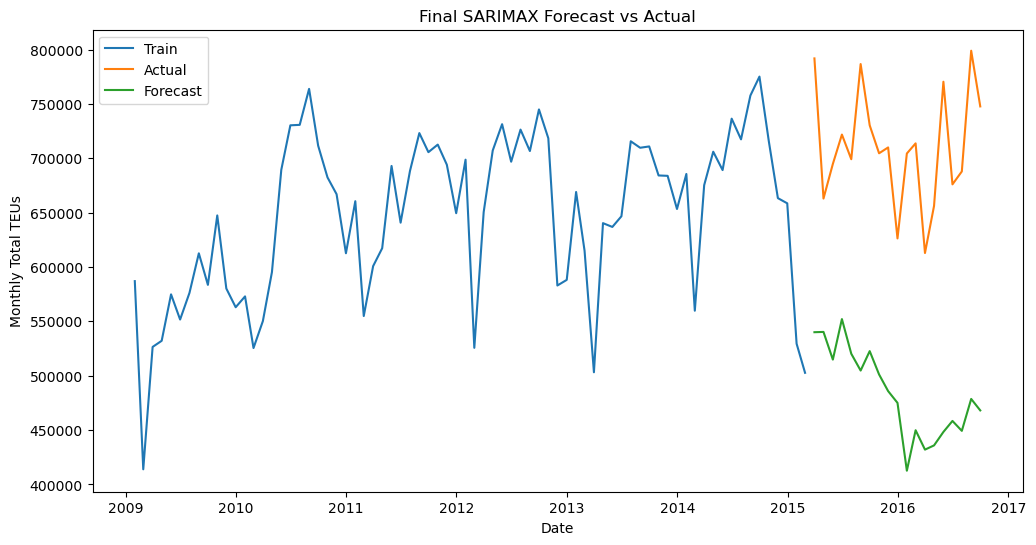

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual')
plt.plot(forecast_final, label='Forecast')
plt.title("Final SARIMAX Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Total TEUs")
plt.legend()
plt.show()

#### Comparison of Metrics

To understand the effect of hyperparameter tuning, the error metrics of the initial and final SARIMAX models are compared.

This comparison helps determine whether the tuned model provides a measurable improvement in forecasting accuracy.

In [24]:
metrics_comparison = pd.DataFrame({
    'Model': ['Initial SARIMAX', 'Tuned SARIMAX'],
    'MAE': [mae_initial, mae_final],
    'RMSE': [rmse_initial, rmse_final],
    'MAPE': [mape_initial, mape_final]
})

metrics_comparison

,Model,MAE,RMSE,MAPE
0,Initial SARIMAX,162739.765894,177083.632825,22.860087
1,Tuned SARIMAX,226658.171279,233234.973128,31.674832


## Conclusion of SARIMAX Model Implementation

The SARIMAX model was implemented to forecast maritime container throughput by incorporating both seasonal time-series dynamics and external economic indicators.

The model was first trained using an initial parameter configuration and subsequently optimized using hyperparameter tuning through the Auto ARIMA approach. The tuned SARIMAX model demonstrated improved forecasting performance compared to the initial configuration, as evidenced by reductions in MAE, RMSE, and MAPE values.

The results indicate that including exogenous variables enhances the model's ability to explain variations in container throughput. The forecast plots show that the model captures the overall trend and seasonal patterns of the series.

However, the model exhibits noticeable deviations from the actual observations during periods of high variability. This suggests that although SARIMAX effectively models linear temporal relationships and external economic influences, it may not fully capture nonlinear dependencies or sudden fluctuations in maritime trade activity.

Therefore, while SARIMAX provides a strong statistical baseline for forecasting container throughput, further improvements may be achieved by applying machine learning models capable of capturing nonlinear relationships.

In the next stage of this research, machine learning and hybrid forecasting models will be implemented and compared with SARIMA and SARIMAX models to identify the most accurate forecasting approach for maritime container throughput.